In [15]:
path = r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-11\data\lev-11_merged.parquet"

# import 
import pandas as pd
import polars as pl
import missingno as msgo
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
colors = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59']  
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

palette = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59', '#ccff33', '#ff36ab', '#e0fbfc', '#3772ff', '#45062e']  
sns.set_palette(palette)

In [18]:
online_cols = [
'Online_Clothing',
'Online_Footwear',
'Online_Furniture',
'Online_Mobile',
'Online_PersonalGoods',
'Online_RecreationGoods',
'Online_HouseholdAppliances',
'Online_Crockery',
'Online_SportsGoods',
'Online_MedicalEquipment',
'Online_Bedding',
]

free_cols = [
'Free_Laptop',
'Num_Free_Laptop',
'Free_Tablet',
'Num_Free_Tablet',
'Free_Mobile',
'Num_Free_Mobile',
'Free_Bicycle',
'Num_Free_Bicycle',
'Free_Scooter',
'Num_Free_Scooter',
'Free_Clothing',
'Num_Free_Clothing',
'Free_Footwear',
'Num_Free_Footwear',
'Free_Other',
'Num_Free_Other',
]

possess_cols = [
'Possess_Television',
'Possess_Radio',
'Possess_Laptop',
'Possess_Mobile',
'Possess_Bicycle',
'Possess_Scooter',
'Possess_Car',
'Possess_Truck',
'Possess_AnimalCart',
'Possess_Refrigerator',
'Possess_WashingMachine',
'Possess_AirCooler',
'TV_Facility_Type',
]

all_cols = (
    online_cols 
    + free_cols
    + possess_cols
)
pdf = pdf[all_cols]

display(f"Desire Filter shape {pdf.shape}")


'Desire Filter shape (28210, 40)'

In [19]:

# str -> int 
pdf = pdf.with_columns(
    [pl.col(col).cast(pl.Int16, strict=False) for col in pdf.columns]
)

display(pdf.schema)


Schema([('Online_Clothing', Int16),
        ('Online_Footwear', Int16),
        ('Online_Furniture', Int16),
        ('Online_Mobile', Int16),
        ('Online_PersonalGoods', Int16),
        ('Online_RecreationGoods', Int16),
        ('Online_HouseholdAppliances', Int16),
        ('Online_Crockery', Int16),
        ('Online_SportsGoods', Int16),
        ('Online_MedicalEquipment', Int16),
        ('Online_Bedding', Int16),
        ('Free_Laptop', Int16),
        ('Num_Free_Laptop', Int16),
        ('Free_Tablet', Int16),
        ('Num_Free_Tablet', Int16),
        ('Free_Mobile', Int16),
        ('Num_Free_Mobile', Int16),
        ('Free_Bicycle', Int16),
        ('Num_Free_Bicycle', Int16),
        ('Free_Scooter', Int16),
        ('Num_Free_Scooter', Int16),
        ('Free_Clothing', Int16),
        ('Num_Free_Clothing', Int16),
        ('Free_Footwear', Int16),
        ('Num_Free_Footwear', Int16),
        ('Free_Other', Int16),
        ('Num_Free_Other', Int16),
        ('Possess_

# Filter Features

In [20]:
online_cols = [
'Online_Clothing',
'Online_Footwear',
]

free_cols = [
'Free_Clothing',
'Num_Free_Clothing',
]

possess_cols = [
'Possess_Television',
'Possess_Laptop',
'Possess_Mobile',
'Possess_Bicycle',
'Possess_Scooter',
'Possess_Car',
'Possess_Refrigerator',
'Possess_WashingMachine',
'Possess_AirCooler',
'TV_Facility_Type',
]

all_cols = (
    online_cols 
    + free_cols
    + possess_cols
)
pdf = pdf[all_cols]

display(f"Desire Filter shape {pdf.shape}")


'Desire Filter shape (28210, 14)'

In [21]:
for col in ['Num_Free_Clothing', 'Free_Clothing']:
    pdf = pdf.with_columns(
    pl.col(col).fill_null(strategy='zero')
)

In [22]:
pc = ['Possess_Television', 'Possess_Laptop', 'Possess_Mobile', 'Possess_Bicycle',
 'Possess_Scooter', 'Possess_Car', 'Possess_Refrigerator', 'Possess_WashingMachine',
 'Possess_AirCooler', 'Online_Clothing', 'Online_Footwear']

for col in pc:
        pdf = pdf.with_columns(
        pl.col(col).fill_null(strategy='zero')
)

In [23]:
pdf = pdf.with_columns(
        pl.col('TV_Facility_Type').fill_null(strategy='forward')
)

In [24]:
pdf.null_count()

Online_Clothing,Online_Footwear,Free_Clothing,Num_Free_Clothing,Possess_Television,Possess_Laptop,Possess_Mobile,Possess_Bicycle,Possess_Scooter,Possess_Car,Possess_Refrigerator,Possess_WashingMachine,Possess_AirCooler,TV_Facility_Type
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0


([<matplotlib.patches.Wedge at 0x11d07a92f90>,
 [Text(0.9704488285440931, 0.5179083617565926, '0'),
  Text(-0.9704486906578381, -0.5179086201256818, '1')],
 [Text(0.5293357246604143, 0.2824954700490505, '15.60%'),
  Text(-0.5293356494497298, -0.2824956109776446, '84.40%')])

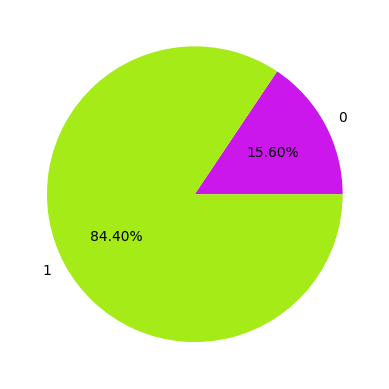

In [ ]:
plt.pie(
    pdf['Online_Clothing'].value_counts()['count'],
    autopct='%1.2f%%',
    labels=pdf['Online_Clothing'].value_counts()['Online_Clothing'],
)

plt.title(f"{col}")
plt.show()

# Functions

In [26]:
def draw_pie(col: str):
    plt.pie(
        pdf[col].value_counts()['count'],
        autopct='%1.2f%%',
        labels=pdf[col].value_counts()[col],
    )

    plt.title(f"{col}")
    plt.show()

In [27]:
pdf.columns

['Online_Clothing',
 'Online_Footwear',
 'Free_Clothing',
 'Num_Free_Clothing',
 'Possess_Television',
 'Possess_Laptop',
 'Possess_Mobile',
 'Possess_Bicycle',
 'Possess_Scooter',
 'Possess_Car',
 'Possess_Refrigerator',
 'Possess_WashingMachine',
 'Possess_AirCooler',
 'TV_Facility_Type']

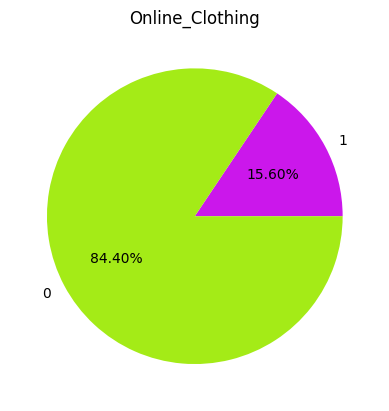

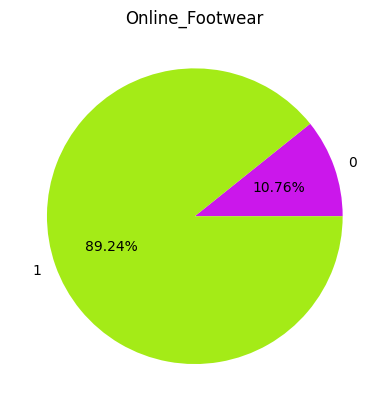

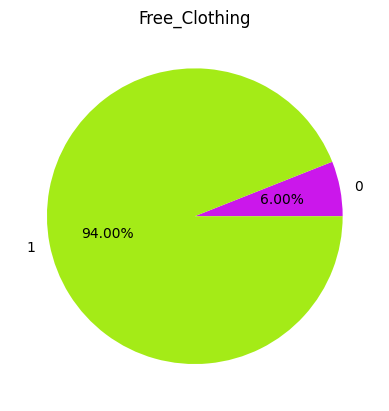

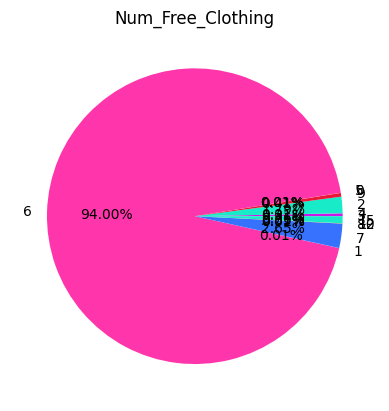

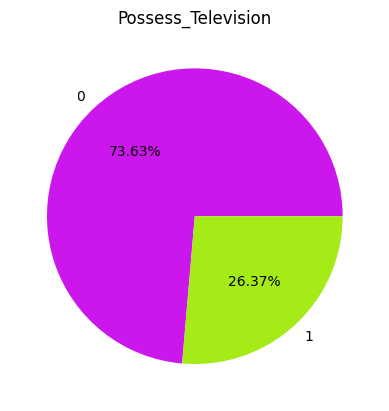

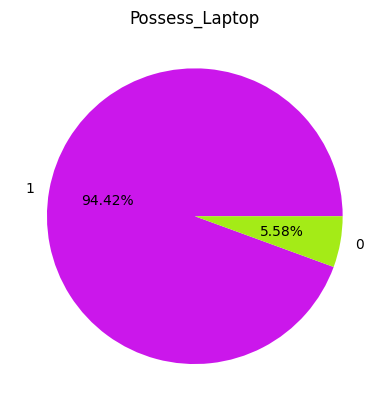

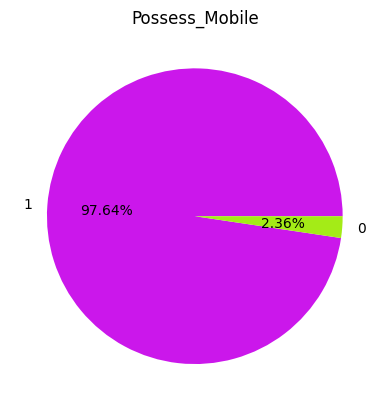

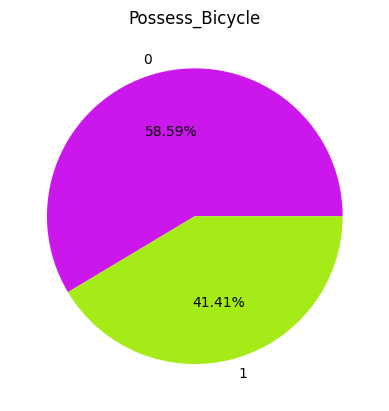

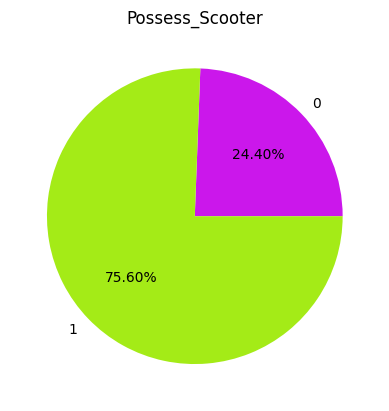

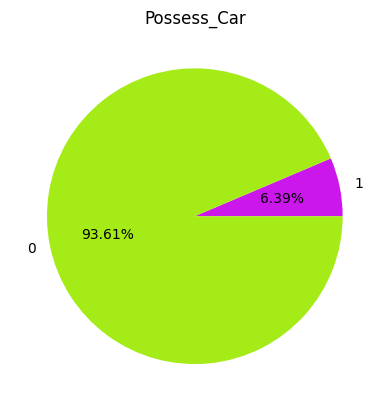

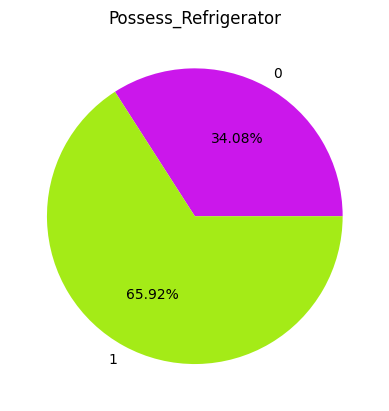

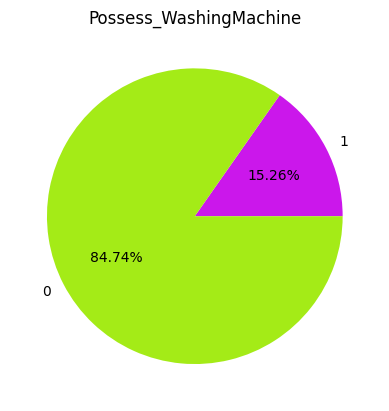

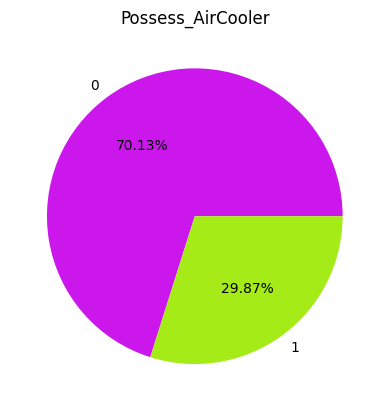

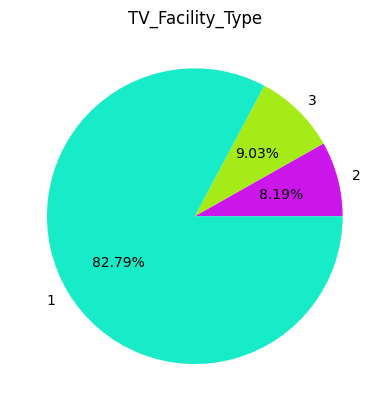

In [ ]:
pc = ['Online_Clothing', 'Online_Footwear', 'Free_Clothing',  'Num_Free_Clothing',
      'Possess_Television', 'Possess_Laptop', 'Possess_Mobile', 'Possess_Bicycle',
      'Possess_Scooter', 'Possess_Car', 'Possess_Refrigerator', 'Possess_WashingMachine',
      'Possess_AirCooler', 'TV_Facility_Type']

for col in pc:
    draw_pie(col)

In [47]:
clo_df =pdf[['Free_Clothing', 'Num_Free_Clothing']].to_pandas()

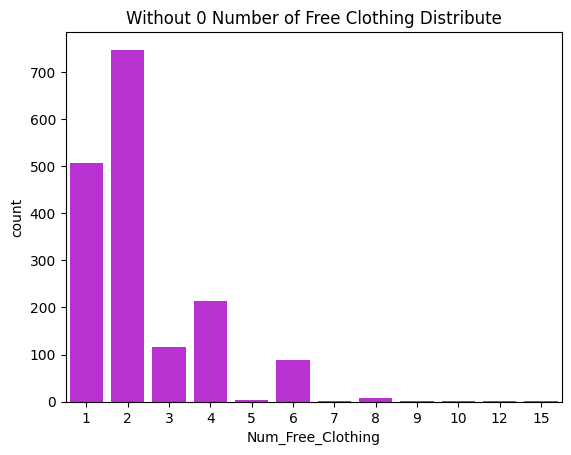

In [48]:
sns.barplot(clo_df[clo_df['Num_Free_Clothing'] != 0]['Num_Free_Clothing'].value_counts())
plt.title('Without 0 Number of Free Clothing Distribute')
plt.show()

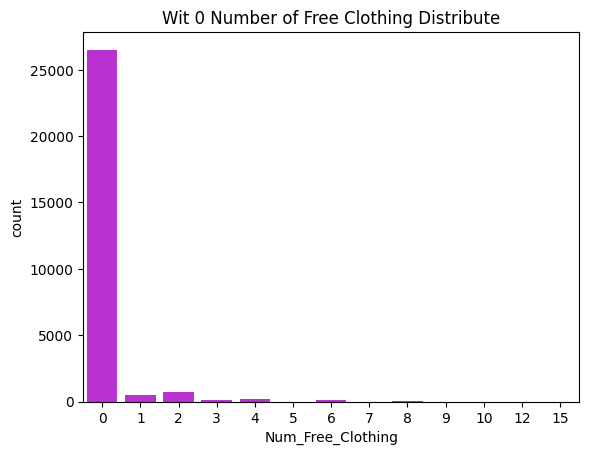

In [50]:
sns.barplot(clo_df['Num_Free_Clothing'].value_counts())
plt.title('Wit 0 Number of Free Clothing Distribute')
plt.show()